Samples found: ['C3_nico_2024', 'C3_taccor_2024', 'C4_nico_2024', 'C4_tacco_2024']
Colour scale: [-0.965, 0.965]


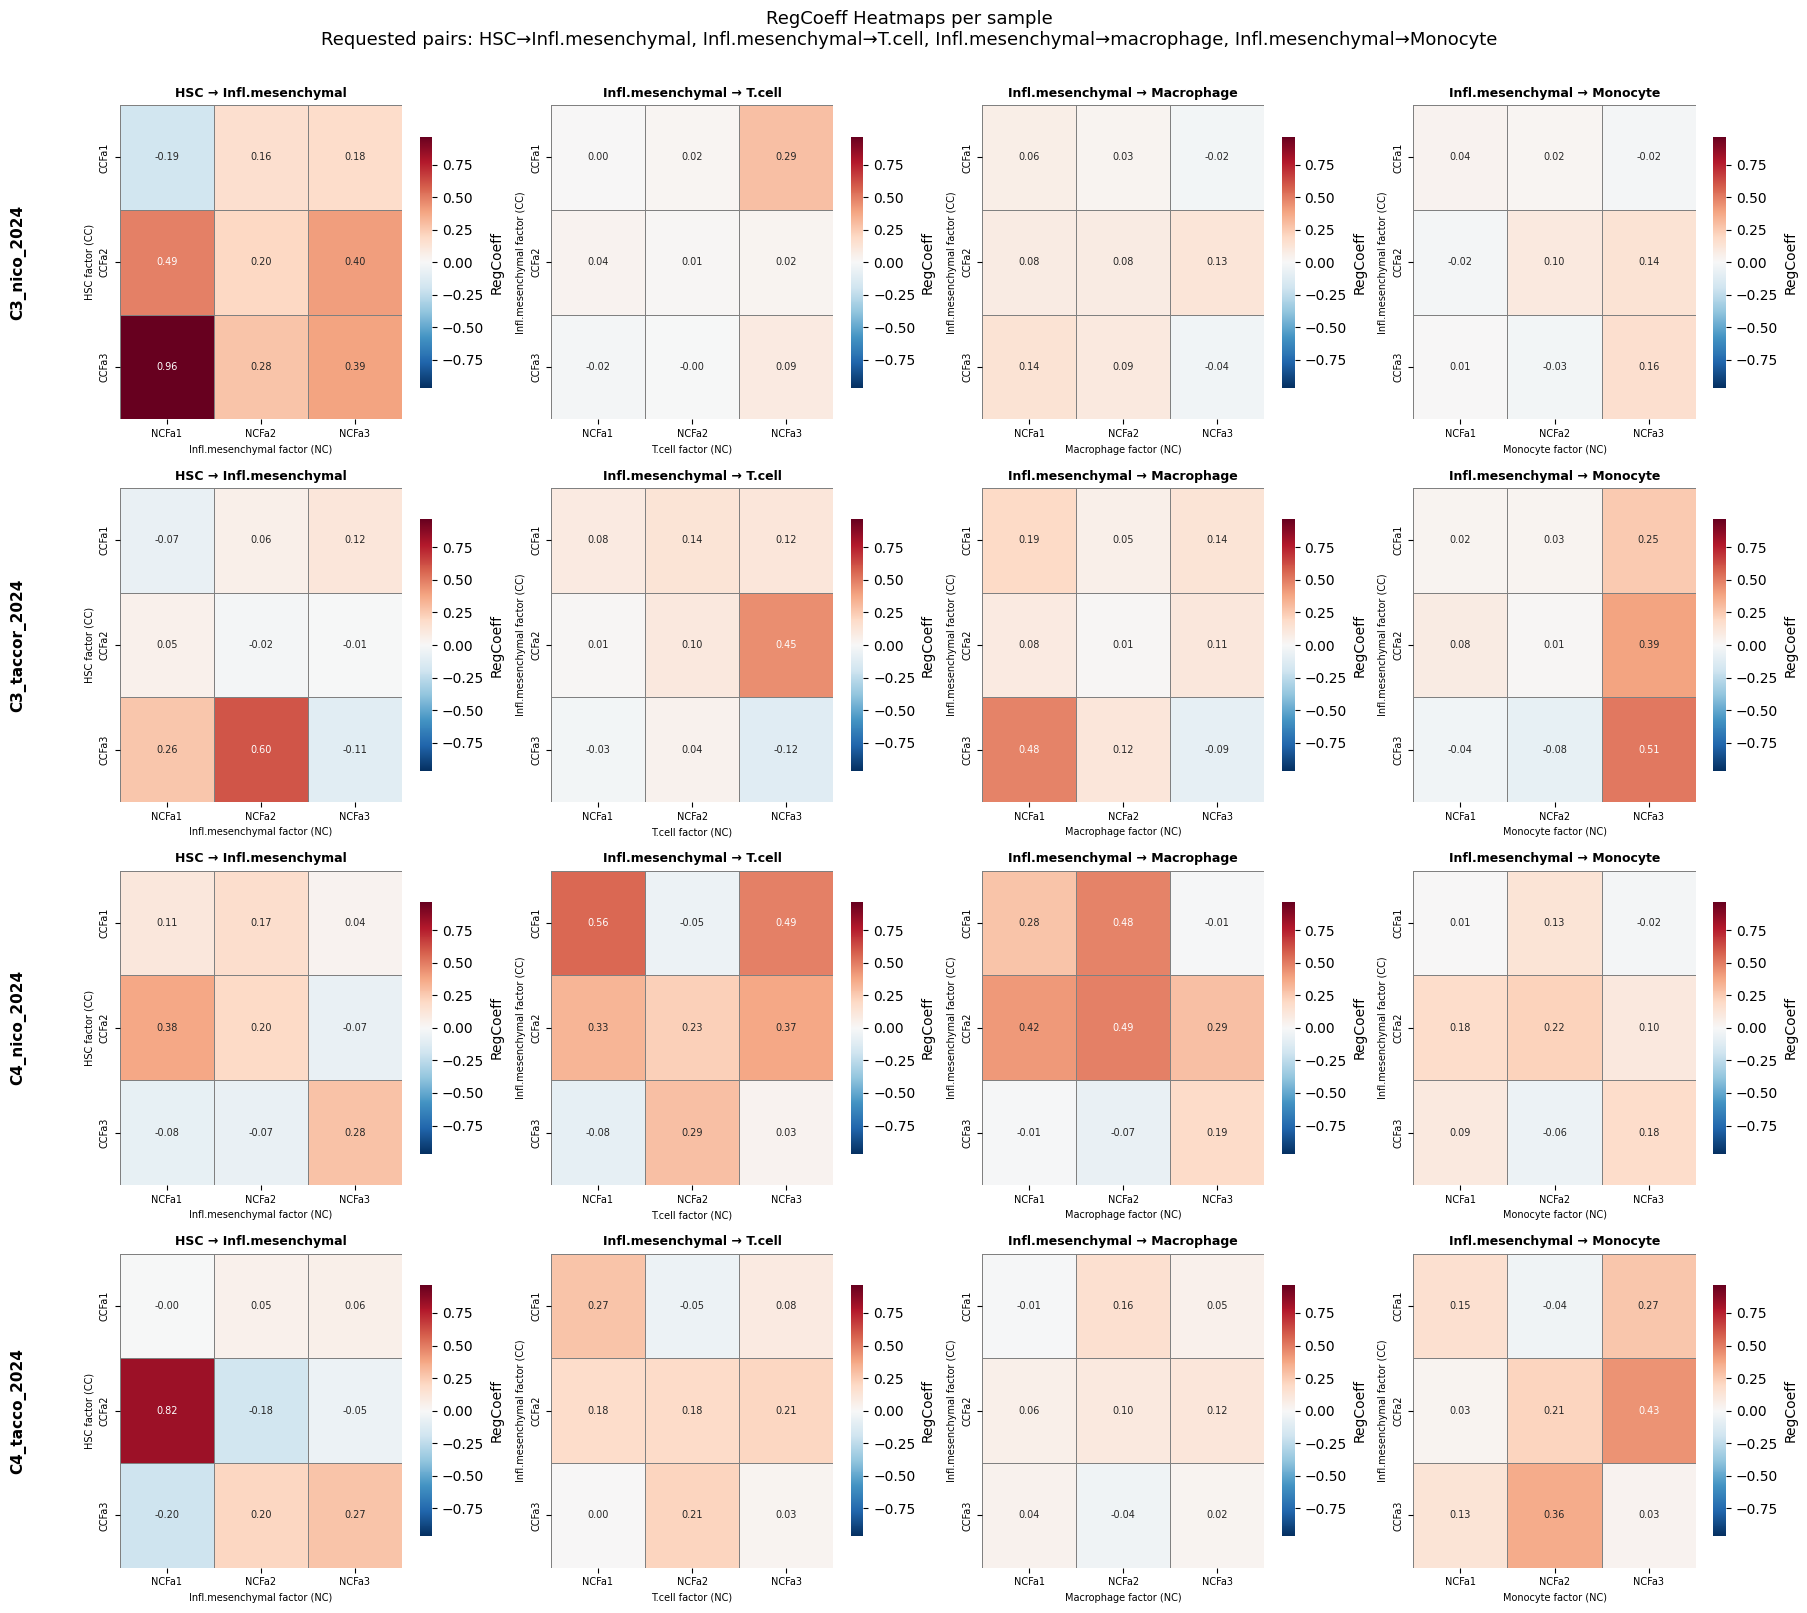

Saved PDF to: /Users/cheung/Documents/Nature_cancer/revision/spatial/C3C4_2024/regcoeff_heatmaps_four_requested_pairs.pdf


In [ ]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
import matplotlib

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
BASE_DIR = os.getcwd()

# Cell type pairs to plot: (CC cell_type, NC cell_type)
# Plot only the requested direction; do not reverse-match or transpose.
PAIRS = [
    ("HSC", "Infl.mesenchymal"),
    ("Infl.mesenchymal", "T.cell"),
    ("Infl.mesenchymal", "Macrophage"),
    ("Infl.mesenchymal", "Monocyte"),
]

def normalize_cell_name(value):
    return re.sub(r"[^a-z0-9]", "", value.strip().lower())

def cell_matches(series, target):
    normalized = series.map(normalize_cell_name)
    target_norm = normalize_cell_name(target)
    aliases = {target_norm}
    if target_norm == "macrophage":
        aliases.update({"macrophages"})
    elif target_norm == "monocyte":
        aliases.update({"monocytes"})
    elif target_norm == "inflmesenchymal":
        aliases.update({"inflmesenchymal"})
    return normalized.isin(aliases)

def parse_regression_summary(filepath):
    """Parse Regression_summary.txt and return a DataFrame with all factor-pair rows."""
    records = []
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line.startswith("CC-Fa"):
                continue
            parts = line.split("\t")
            if len(parts) < 6:
                continue
            try:
                cc_fa = parts[0].strip()
                cc_cell = parts[1].strip()
                nc_fa = parts[3].strip()
                nc_cell = parts[4].strip()
                regcoeff_match = re.search(r'RegCoeff=([-\d.eE+]+)', parts[5])
                if not regcoeff_match:
                    continue
                regcoeff = float(regcoeff_match.group(1))
                records.append({
                    "CC_fa": cc_fa,
                    "CC_cell": cc_cell,
                    "NC_fa": nc_fa,
                    "NC_cell": nc_cell,
                    "RegCoeff": regcoeff,
                })
            except (IndexError, ValueError):
                continue
    return pd.DataFrame(records)

def fa_sort_key(fa_str):
    m = re.search(r'(\d+)', fa_str)
    return int(m.group()) if m else 0

def get_pivot_for_pair(df, cell_A, cell_B):
    """Return a pivot table for the exact CC=cell_A and NC=cell_B direction only."""
    sub_fwd = df[cell_matches(df["CC_cell"], cell_A) & cell_matches(df["NC_cell"], cell_B)]
    if not sub_fwd.empty:
        pivot = sub_fwd.pivot_table(index="CC_fa", columns="NC_fa", values="RegCoeff", aggfunc="first")
        pivot.index.name = f"{cell_A} factor (CC)"
        pivot.columns.name = f"{cell_B} factor (NC)"
        pivot = pivot.sort_index(key=lambda x: pd.Series([fa_sort_key(v) for v in x], index=x))
        pivot = pivot.reindex(sorted(pivot.columns, key=fa_sort_key), axis=1)
        return pivot
    return None

def make_heatmap(ax, pivot, title, vmin, vmax):
    """Plot a single heatmap on the given axis."""
    if pivot is None:
        ax.set_facecolor("#f0f0f0")
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, fontsize=9, color="gray")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(title, fontsize=9, fontweight="bold")
        return

    def rename_fa(labels):
        return [l.replace("CC-Fa", "CCFa").replace("NC-Fa", "NCFa") for l in labels]

    display = pivot.copy()
    display.index = rename_fa(display.index.tolist())
    display.columns = rename_fa(display.columns.tolist())

    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    sns.heatmap(display, ax=ax, cmap="RdBu_r", norm=norm, annot=True, fmt=".2f", linewidths=0.5, linecolor="gray", cbar_kws={"shrink": 0.8, "label": "RegCoeff"}, annot_kws={"size": 7})
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlabel(pivot.columns.name, fontsize=7)
    ax.set_ylabel(pivot.index.name, fontsize=7)
    ax.tick_params(axis="both", labelsize=7)

samples = sorted([
    d for d in os.listdir(BASE_DIR)
    if os.path.isdir(os.path.join(BASE_DIR, d))
    and os.path.isfile(os.path.join(BASE_DIR, d, "Regression_summary.txt"))
])
print("Samples found:", samples)

sample_dfs = {}
for sample in samples:
    fp = os.path.join(BASE_DIR, sample, "Regression_summary.txt")
    sample_dfs[sample] = parse_regression_summary(fp)

all_coeffs = []
for df in sample_dfs.values():
    for cell_A, cell_B in PAIRS:
        pivot = get_pivot_for_pair(df, cell_A, cell_B)
        if pivot is not None:
            all_coeffs.extend(pivot.values.flatten().tolist())

vmax = max(abs(np.array(all_coeffs))) if all_coeffs else 1.0
vmin = -vmax
print(f"Colour scale: [{vmin:.3f}, {vmax:.3f}]")

n_samples = len(samples)
n_pairs = len(PAIRS)
pair_labels = [f"CC: {a}\nNC: {b}" for a, b in PAIRS]

fig, axes = plt.subplots(n_samples, n_pairs, figsize=(n_pairs * 4.5, n_samples * 4), squeeze=False)

for row_idx, sample in enumerate(samples):
    df = sample_dfs[sample]
    for col_idx, (cell_A, cell_B) in enumerate(PAIRS):
        ax = axes[row_idx, col_idx]
        pivot = get_pivot_for_pair(df, cell_A, cell_B)
        title = f"{cell_A} → {cell_B}"
        make_heatmap(ax, pivot, title, vmin, vmax)
    row_anchor = axes[row_idx, 0]
    row_anchor.text(-0.36, 0.5, sample, transform=row_anchor.transAxes, rotation=90, ha="center", va="center", fontsize=11, fontweight="bold", clip_on=False)

for col_idx, label in enumerate(pair_labels):
    axes[0, col_idx].set_title(axes[0, col_idx].get_title(), fontsize=9, fontweight="bold")

plt.suptitle("RegCoeff Heatmaps per sample\nRequested pairs: HSC→Infl.mesenchymal, Infl.mesenchymal→T.cell, Infl.mesenchymal→macrophage, Infl.mesenchymal→Monocyte", fontsize=13, y=1.005)
plt.tight_layout()

outpath = os.path.join(BASE_DIR, "regcoeff_heatmaps_four_requested_pairs.pdf")
plt.savefig(outpath, bbox_inches="tight", dpi=150)
plt.show()
print("Saved PDF to:", outpath)

In [7]:
from pathlib import Path
import pandas as pd
import gseapy as gp

base_dir = Path.cwd()
excel_files = sorted(base_dir.rglob('gene_correlation.xlsx'))

factors = ['Fa1', 'Fa2', 'Fa3']
selected_cell_types = ['HSC', 'Infl.mesenchymal', 'T.cell', 'Macrophage', 'Monocyte']
all_factor_tables = {}
all_enrichment_tables = {}
significant_pathway_tables = []

for excel_path in excel_files:
    dataset_name = excel_path.parent.name
    correlation_df = pd.read_excel(excel_path, sheet_name=1)
    columns = correlation_df.columns.tolist()

    all_factor_tables[dataset_name] = {}
    all_enrichment_tables[dataset_name] = {}

    for cell_type in selected_cell_types:
        if cell_type not in columns:
            print(f"[{dataset_name} - {cell_type}] Skipped: '{cell_type}' column not found")
            continue

        cell_index = columns.index(cell_type)
        cell_cols = columns[cell_index:cell_index + 4]
        if len(cell_cols) < 4:
            print(f"[{dataset_name} - {cell_type}] Skipped: fewer than 3 columns after {cell_type}")
            continue

        cell_df = correlation_df[cell_cols].copy()
        cell_df.columns = [cell_type] + factors

        cell_df = cell_df.dropna(subset=[cell_type]).copy()
        cell_df.index = cell_df[cell_type].astype(str)
        cell_df = cell_df.drop(columns=[cell_type], errors='ignore')
        if cell_type in cell_df.index:
            cell_df = cell_df.drop(index=cell_type)

        all_factor_tables[dataset_name][cell_type] = {}
        all_enrichment_tables[dataset_name][cell_type] = {}

        for factor in factors:
            factor_df_sorted = cell_df[[factor]].dropna().sort_values(by=factor, ascending=False)
            all_factor_tables[dataset_name][cell_type][factor] = factor_df_sorted

            top_genes = factor_df_sorted.index.tolist()[:100]
            filtered_genes = [g for g in top_genes if not str(g).startswith('RP')]
            filtered_genes = list(dict.fromkeys(filtered_genes))

            if len(filtered_genes) < 5:
                print(f"[{dataset_name} - {cell_type} - {factor}] Skipped enrichment: <5 usable genes")
                continue

            try:
                enr = gp.enrichr(
                    gene_list=filtered_genes,
                    gene_sets='Reactome_Pathways_2024',
                    organism='Human',
                    outdir=None,
                    cutoff=0.05,
                )
            except Exception as exc:
                print(f"[{dataset_name} - {cell_type} - {factor}] Enrichr failed: {exc}")
                continue

            enr_res = enr.results.copy()
            if enr_res.empty:
                print(f"[{dataset_name} - {cell_type} - {factor}] No enrichment results")
                continue

            sig = enr_res[enr_res['Adjusted P-value'] < 0.05].copy()
            if sig.empty:
                print(f"[{dataset_name} - {cell_type} - {factor}] No significant pathways (Adj P < 0.05)")
                continue

            keep_cols = [
                c for c in ['Term', 'P-value', 'Adjusted P-value', 'Odds Ratio', 'Combined Score']
                if c in sig.columns
            ]
            sig = sig[keep_cols].sort_values('Adjusted P-value', ascending=True)
            sig.insert(0, 'Factor', factor)
            sig.insert(0, 'CellType', cell_type)
            sig.insert(0, 'Dataset', dataset_name)

            all_enrichment_tables[dataset_name][cell_type][factor] = sig
            significant_pathway_tables.append(sig)

if significant_pathway_tables:
    significant_pathways_df = pd.concat(significant_pathway_tables, ignore_index=True)
else:
    significant_pathways_df = pd.DataFrame(
        columns=['Dataset', 'CellType', 'Factor', 'Term', 'P-value', 'Adjusted P-value', 'Odds Ratio', 'Combined Score']
    )

print(f"Datasets detected: {len(excel_files)}")
print(f"Datasets processed: {len(all_factor_tables)}")
print(f"Total significant pathways: {len(significant_pathways_df)}")

[C3_taccor_2024 - Macrophage - Fa2] No significant pathways (Adj P < 0.05)
[C4_nico_2024 - Macrophage - Fa1] No significant pathways (Adj P < 0.05)
[C4_nico_2024 - Monocyte - Fa3] No significant pathways (Adj P < 0.05)
Datasets detected: 4
Datasets processed: 4
Total significant pathways: 5811
